 # Figures of the CMB-S4 $\mathbf{N}_\mathbf{eff}$ Forecasting Paper

All figures of arXiv:26XX.XXXXX.

## Preliminaries

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import healpy as hp

from scipy.interpolate import UnivariateSpline as interpolate
from scipy.ndimage import zoom as sp_zoom

import os
import subprocess

In [2]:
plt.style.use('data/mine.mplstyle')
mpl.rcParams['text.latex.preamble'] = r'\usepackage{siunitx}'
GOLDEN_RATIO = (1+np.sqrt(5.))/2.

## Underlying Data

In [3]:
# # Figure 1: Thermal relics
# FIGURE1 = np.load('data/delta-neff_thermal-relics.npy', allow_pickle=True).item()

# # 95% c.l. on Delta Neff
# CVL = np.load('data/sigma-neff_cvl_ellmax.npy', allow_pickle=True).item()
# CONSTRAINTS = {'Current': 2*0.12,                            #\sigma(\Neff) from Planck + ACT + SPT, arXiv:2506.20707
#                'S4': 2*0.03,                                 # S4 science target
#                'SVL': 2*CVL['sigma_neff'][10]/np.sqrt(0.6),  # Sample-variance-limited survey over fsky = 0.60\% and ellmax = 5000
#                'CVL': 2*CVL['sigma_neff'][10]                # Cosmic-variance-limited survey (fsky = 1) with ellmax = 5000
#               }
# FIGURE1['Constraints (2sigma)'] = CONSTRAINTS

In [4]:
# # Figure 2: Survey Footprints
# # def healpix_rotate_coords(hmap, coord, beam_to_use_for_smoothing = None, threshold = 0.001):
# #     """
# #     coord = ['C', 'G'] to convert a map in RADEC to Gal.    
# #     """

# #     #get map pixel
# #     pixel = np.arange(len(hmap))

# #     #get angles in this map first
# #     nside = hp.get_nside(hmap)
# #     angles = hp.pix2ang(nside, pixel)

# #     #rotate the angles to the desired new coordinate
# #     rotated_angles = hp.Rotator(coord=coord)(*angles)

# #     #get the rotated pixel values
# #     rotated_pixel = hp.ang2pix(nside, *rotated_angles)

# #     #initialise new map
# #     rot_hmap = np.zeros(len(pixel))

# #     #push the original map pixel to the new map (in the rotated pixel positions)
# #     rot_hmap[rotated_pixel] = hmap[pixel]
# #     if beam_to_use_for_smoothing is not None:
# #         rot_hmap = hp.smoothing(rot_hmap, fwhm = np.radians(beam_to_use_for_smoothing))
# #         rot_hmap[rot_hmap>threshold] = 1.
# #         rot_hmap[rot_hmap<threshold] = 0.

# #     return rot_hmap


# # gal_mask = hp.read_map('github_srini/data/HFI_Mask_GalPlane-apo0_512_R2.00.fits', field = (5))
# # gal_mask = healpix_rotate_coords(gal_mask, ['G', 'C'], beam_to_use_for_smoothing=1.)

# # dust_map = hp.read_map('github_srini/data/COM_CompMap_dust-commander_0256_R2.00.fits')

# # opfname = 'github_srini/data/hmap_patches_noisemap_dictionary.npy'
# # hmap_patches_noisemap_dic = np.load(opfname, allow_pickle=True).item()

# # splat = hmap_patches_noisemap_dic['splat_dc0']
# # splat[splat>0.4] = hp.UNSEEN # SPTLAT - Only have the deepest patch
# # nside_deep = hp.npix2nside(len(splat))
# # valid_mask = (splat != hp.UNSEEN) & (gal_mask != 0)
# # boundary_pix = []
# # for px in np.where(valid_mask)[0]:
# #     neighbours = hp.get_all_neighbours(nside_deep, px)
# #     neighbours = neighbours[neighbours >= 0]  # remove -1 (missing neighbours at poles)
# #     if np.any(~valid_mask[neighbours]):
# #         boundary_pix.append(px)
# # boundary_pix = np.array(boundary_pix)
# # theta, phi = hp.pix2ang(nside_deep, boundary_pix)
# # splat_ra_boundary  = np.degrees(phi)
# # splat_dec_boundary = 90. - np.degrees(theta)


# # FIGURE2 = {'dust map': dust_map, 
# #            'pbd footprint': {'wide': {'RA': [-180, 180], 'DEC': [-62, 25]},
# #                              'ultra-deep': {'RA': splat_ra_boundary, 'DEC': splat_dec_boundary}},
# #            'revised footprint': {'wide': hmap_patches_noisemap_dic['lat_wide'],
# #                                  'delensing': hmap_patches_noisemap_dic['lat_delensing'],
# #                                  'galactic mask': gal_mask},
# #            'info': {'galactic mask': 'HFI_Mask_GalPlane-apo0_512_R2.00.fits, field=(5), rotated coordinates to galactic',
# #                     'dust map': 'COM_CompMap_dust-commander_0256_R2.00.fits',
# #                     'pbd footprint': 'Right ascension and declination',
# #                     'revised footprint': ['Four patches each for the Hybrid Wide and Hybrid Delensing surveys '
# #                                           + 'of the revised configuration; additionally the Planck galactic mask '
# #                                           + "'HFI_Mask_GalPlane-apo0_512_R2.00.fits' with field=(5) and coordinates"
# #                                           + 'rotated to galactic'][0]
# #                    }
# #           }

# # np.save('data/footprints.npy', FIGURE2)

# FIGURE2 = np.load('data/footprints.npy', allow_pickle=True).item()

In [5]:
# # Figure 3: Footprints
# # DATA = np.load('data/cmbs4_nl_and_fgcl_dict.npy', allow_pickle=True).item()
# # #SPECTRA = np.load('data/spectra_class_fiducial_tetralith.npy', allow_pickle=True).item()
# # #SPECTRA = np.load('data/spectra_class_fiducial_precision_tetralith.npy', allow_pickle=True).item()
# # SPECTRA = np.transpose(np.loadtxt('data/output_planck_r_0.0_2015_cosmo_lensedCls.dat'))

# # FIGURE3 = {}
# # for num, spec in enumerate(['TT', 'EE']):
# #     FIGURE3[spec] = {}
# #     for typ in ['cmb', 'noise', 'galdust', 'galsync', 'radio', 'tsz', 'ksz', 'cib']:
# #         FIGURE3[spec][typ] = {}
# #         nu_arr_to_plot = np.unique([nu1 for (nu1, nu2) in list(DATA['fg_cl_dic'][spec][typ].keys())])
# #         nu_mapping_dict = {27: 25, 39: 40, 93: 90, 145: 150, 225: 230, 278: 280}
# #         for nu in nu_arr_to_plot:
# #             if typ == 'cmb':
# #                 #FIGURE3[spec][typ][nu_mapping_dict[nu]] = 2.7255e6**2 * SPECTRA[f'cl{spec}lensed'][:6001]
# #                 dl_fac = SPECTRA[0] * (SPECTRA[0] + 1) / (2. * np.pi)
# #                 spectra_temp = np.append([0., 0.], 2.7255e6**2 * SPECTRA[num+1] / dl_fac)[:6001]
# #                 FIGURE3[spec][typ][nu_mapping_dict[nu]] = spectra_temp
# #             else:
# #                 FIGURE3[spec][typ][nu_mapping_dict[nu]] = DATA['fg_cl_dic'][spec][typ][(nu, nu)][:6001]
# # np.save('data/foregrounds.npy', FIGURE3)

# FIGURE3 = np.load('data/foregrounds.npy', allow_pickle=True).item()

In [6]:
# # Figure 4: ILC Residuals
# # DATA = {'wide': np.load('data/s4wide_202310xx_pbdr_config_ilc_galaxy1_27-39-93-145-225-278_TT-EE_galmask2_AZ_lmax6500_for7years.npy',
# #                         allow_pickle=True).item(),
# #         'deep': np.load('data/s4deepv3r025_202310xx_pbdr_config_ilc_galaxy0_20-27-39-93-145-225-278_TT-EE_lmax6500_for7years.npy',
# #                         allow_pickle=True).item()}
# # #SPECTRA = np.load('data/spectra_class_fiducial_tetralith.npy', allow_pickle=True).item()
# # #SPECTRA = np.load('data/spectra_class_fiducial_precision_tetralith.npy', allow_pickle=True).item()
# # SPECTRA = np.transpose(np.loadtxt('data/output_planck_r_0.0_2015_cosmo_lensedCls.dat'))
        
# # def noise_spec(el, beamwidth, Delta, el_knee, alpha_knee):
# #     arcmin_fac = np.pi/(60*180)
# #     exponent = el*(el+1) * (beamwidth * arcmin_fac)**2 / (8 * np.log(2))
# #     if 0 in np.asarray(el):
# #         atmosphere = np.array([1 + (l/el_knee)**(-alpha_knee) if l != 0 else 0 for l in np.asarray(el)])
# #     return (Delta * arcmin_fac)**2 * np.exp(exponent) * atmosphere

# # num = 0
# # FIGURE4 = {}
# # for num, spec in enumerate(['TT', 'EE']):
# #     FIGURE4[spec] = {}
# #     tp = 'T' if spec == 'TT' else 'P'
# #     for survey in ['wide', 'deep']:
# #         FIGURE4[spec][survey] = {}
# #         FIGURE4[spec][survey]['ell'] = DATA[survey]['el'][:6001]
# #         #FIGURE4[spec][survey]['cmb'] = 2.7255e6**2 * SPECTRA[f'cl{spec}lensed'][:6001]
# #         dl_fac = SPECTRA[0] * (SPECTRA[0] + 1) / (2. * np.pi)
# #         FIGURE4[spec][survey]['cmb'] = np.append([0., 0.], 2.7255e6**2 * SPECTRA[num+1] / dl_fac)[:6001]
# #         FIGURE4[spec][survey]['ilc'] = DATA[survey]['cl_residual'][spec][:6001]
# #         for nu in DATA[survey]['beam_noise_dic'][tp]:
# #             nu_mapping_dict = {20: 20, 27: 25, 39: 40, 93: 90, 145: 150, 225: 230, 278: 280}
# #             noise_spectrum = noise_spec(DATA[survey]['el'][:6001], DATA[survey]['beam_noise_dic'][tp][nu][0],
# #                                         DATA[survey]['beam_noise_dic'][tp][nu][1], DATA[survey]['elknee_dic'][tp][nu][0],
# #                                         DATA[survey]['elknee_dic'][tp][nu][1])
# #             FIGURE4[spec][survey][f'nl_{nu_mapping_dict[nu]}'] = noise_spectrum
# # np.save('data/internal-linear-combination.npy', FIGURE4)

# FIGURE4 = np.load('data/internal-linear-combination.npy', allow_pickle=True).item()

In [7]:
# # Figure 5: DRAFT Pipeline
# tex_path = '../draft_pipeline/draft_pipeline.tex'
# with open(tex_path, "r", encoding="utf-8") as file:
#     tex_code = file.read()

# FIGURE5 = {'TeX code': tex_code}

In [8]:
# # Figure 6: Neff as function of time
# # pldict = np.load('results/neff/consolidated_s4_allchile_config_results.npy', allow_pickle=True).item()
# # DATA_S4_REVISED = {'Calendar year': np.insert(pldict['aso_opt+final'][0], 4, pldict['aso_opt'][0][4]), #Inserting 2033 from ASO-Goal
# #                    'sigma_neff':  np.insert(pldict['aso_opt+final'][1], 4, pldict['aso_opt'][1][4]), #Inserting 2033 from ASO-Goal
# #                    'info': 'ASO-Goal + CMB-S4, with ASO and CMB-S4 starting in 2028 and 2033, respectively'}
# # DATA_S4_REVISED['years'] = DATA_S4_REVISED['Calendar year'] - 2033
# # del DATA_S4_REVISED['Calendar year']
# # np.save('data/sigma-neff_s4-revised_time.npy', DATA_S4_REVISED)

# CVL = np.load('data/sigma-neff_cvl_ellmax.npy', allow_pickle=True).item()

# FIGURE6 = {'s4-pbd': np.load('data/sigma-neff_s4-pbd_time.npy', allow_pickle=True).item(),
#            's4-pole': np.load('data/sigma-neff_s4-pole_time.npy', allow_pickle=True).item(),
#            's4-revised': np.load('data/sigma-neff_s4-revised_time.npy', allow_pickle=True).item(),
#            'cvl': CVL['sigma_neff'][10], 'svl': CVL['sigma_neff'][10]/np.sqrt(0.6)}

In [9]:
# # Figure 7: Survey design
# # from misc import elizaTools_new as et_new

# # jobNamePlanck = "misc/s4contourplot/fisher_Planck_lmaxTT3000"
# # jobNameS4 = "misc/s4contourplot/fisher_s4_lmaxTT3000"

# # nExps = 20
# # sTypes = ["unlensed", "lensed", "delensed"]
# # gTypes = ["Gaussian", "nonGaussian"]
# # noiseRange = np.arange(0.1, 2.1, 0.1)
# # fskyRange = np.arange(0.1, 1.1, 0.05)


# # fishersPlanck = et_new.loadGaussianNG(jobName = jobNamePlanck, pythonFlag = 3, returnCosmoParams = False)
# # fishersS4, cosmoParams = et_new.loadGaussianNG(jobName = jobNameS4, pythonFlag = 3, returnCosmoParams = True)

# # nNoises = len(noiseRange)
# # nSkies = len(fskyRange)
# # NeffSigmas = np.zeros((nNoises,nSkies))
# # NeffIndex = cosmoParams.index('N_eff')
# # mnuIndex = cosmoParams.index('mnu')
# # gaussToUse = 'Gaussian'
# # spectToUse = 'delensed'


# # NeffSigmas = np.zeros((nNoises, nSkies))
# # NeffIndex = cosmoParams.index('N_eff')

# # # fisherS4(f) + fisherPl(0.6-f) + tau -> invert -> sqrt
# # totalFishers = dict()
# # for i in range(0,nSkies):
# #     fishersS4Sky = et_new.addfsky(fishersS4, fskyRange[i])
# #     fishersPlanckSky = et_new.addfsky(fishersPlanck, min(0.6-fskyRange[i],0))
# #     fishersS4Tau = et_new.addTau(fishersS4Sky, cosmoParams)
# #     totalFishers[i] = et_new.addPlanckFisher(fishersS4Tau, fishersPlanckSky)
# # for i in range(0,nNoises):
# #     for j in range (0,nSkies):
# #         sigmaMat = et_new.invertFishers(totalFishers[j])[gaussToUse][spectToUse][i]
# #         NeffSigmas[i][j] = np.sqrt(sigmaMat[NeffIndex][NeffIndex])

# # # totalFishers from above but fixing mnu
# # NeffSigmasFixMnu = np.zeros((nNoises,nSkies))
# # paramsToFix = ['mnu']

# # for i in range(0,nNoises):
# #     for j in range (0,nSkies):
# #         fisherMat, cosmoParamsFixMnu = (et_new.fixParametersInFisher(totalFishers[j][gaussToUse]\
# #                                                                      [spectToUse][i],
# #                                              cosmoParams = cosmoParams,
# #                                              paramsToFix = paramsToFix,
# #                                              returnFixedParamList = True))
# #         NeffIndexFixMnu = cosmoParamsFixMnu.index('N_eff')
# #         sigmaMat = et_new.invertFisher(fisherMat)
# #         NeffSigmasFixMnu[i][j] = np.sqrt(sigmaMat[NeffIndexFixMnu][NeffIndexFixMnu])


# # DATA_design = {'noise_range': noiseRange, 'fsky_range': fskyRange, 'sigma_neff': NeffSigmasFixMnu,
# #                'info': ["'sigma_neff' contains the forecasted one-sigma uncertainty for Neff with fixed neutrino masses"
# #                         + "based on Fisher matrices with Gaussian covariance and delensed spectra"][0]} # run on 2021-11-05
# # np.save('data/sigma-neff_survey-design', DATA_design)

# FIGURE7 = np.load('data/sigma-neff_survey-design.npy', allow_pickle=True).item()

In [10]:
# # Figure 8: Neff as function of maximum multipole
# # ...

# FIGURE8 = {'s4': np.load('data/sigma-neff_s4-cd_ellmax.npy', allow_pickle=True).item(),
#            'cvl': np.load('data/sigma-neff_cvl_ellmax.npy', allow_pickle=True).item()}

In [11]:
# All figures
# all_data = {'Figure 1': FIGURE1, 'Figure 2': FIGURE2, 'Figure 3': FIGURE3, 'Figure 4': FIGURE4,
#             'Figure 5': FIGURE5, 'Figure 6': FIGURE6, 'Figure 7': FIGURE7, 'Figure 8': FIGURE8}
# np.save('data/figure_data_neff', all_data)

all_data = np.load('data/figure_data_neff.npy', allow_pickle=True).item()

## Figures

### Figure 1: Thermal Light Relic Contribution to $\mathbf{N}_\mathbf{eff}$

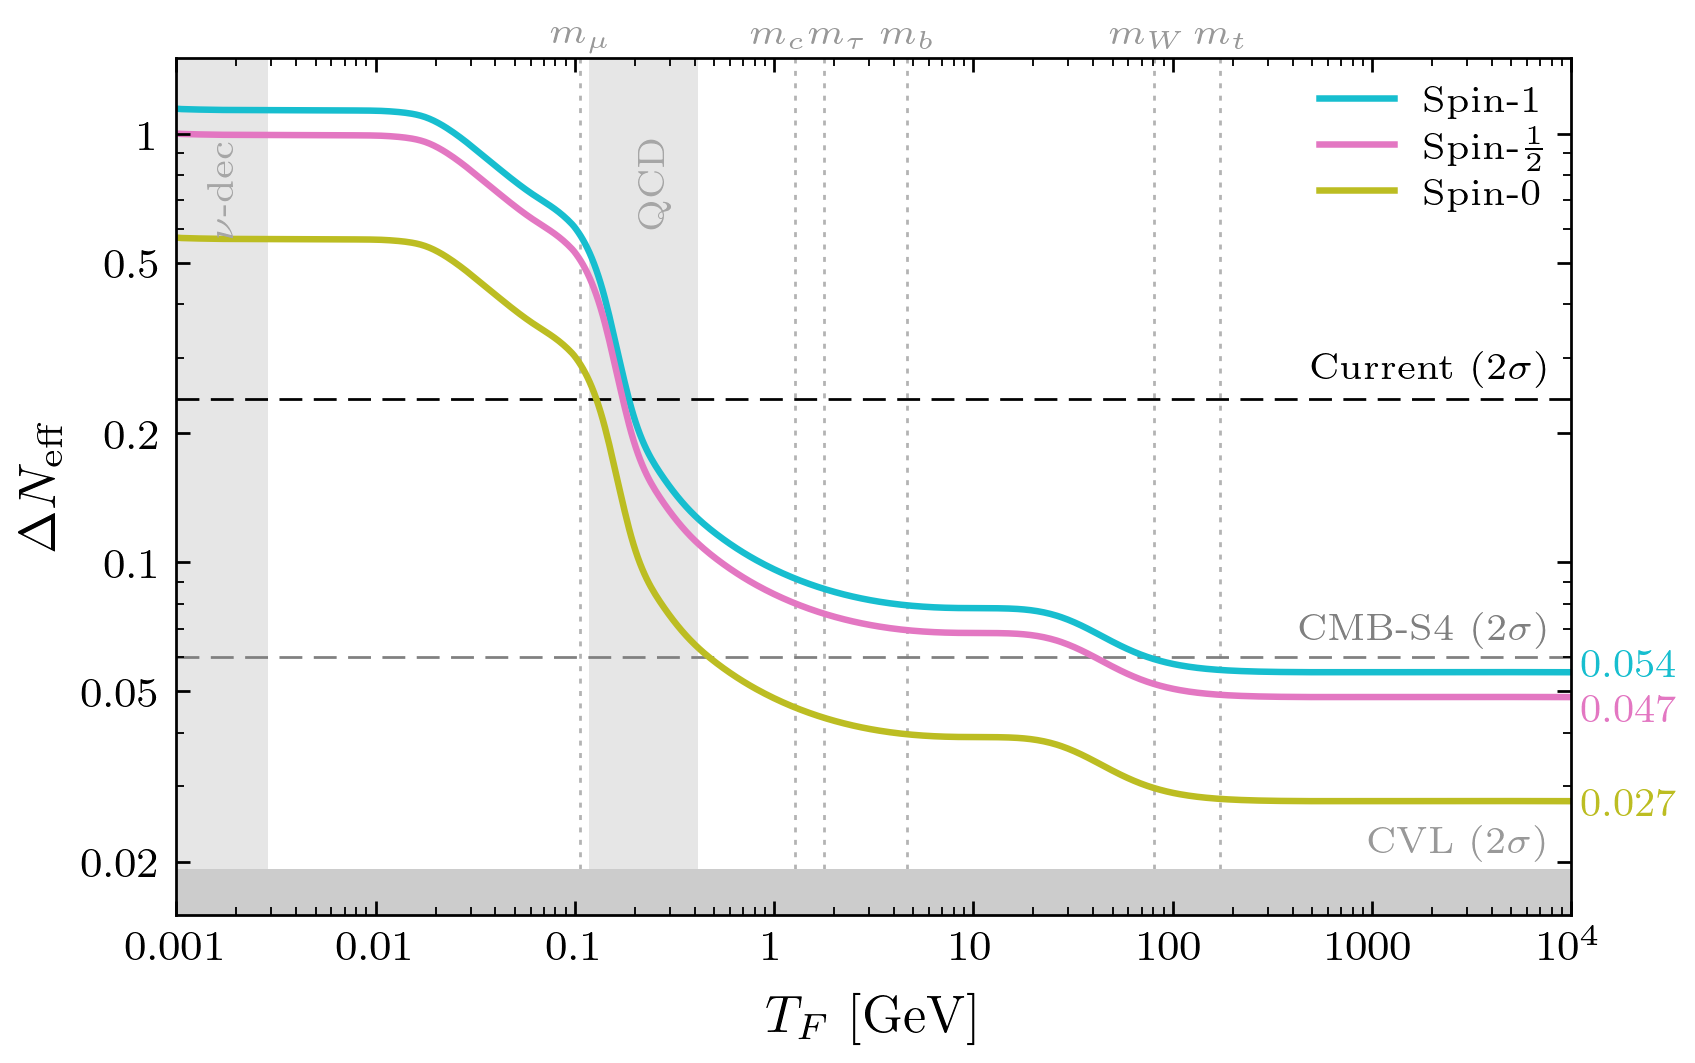

In [12]:
SHORT_DASHES = (1.8, 2.71)
LONG_DASHES = (mpl.rcParams['lines.linewidth']*6.4, mpl.rcParams['lines.linewidth']*3.2)

FIGURE1 = all_data['Figure 1']
temp = FIGURE1['temp']
masses = FIGURE1['particle masses']
deltaNeff = FIGURE1['Delta Neff (combined)']
CONSTRAINTS = FIGURE1['Constraints (2sigma)']


plt.figure(figsize=(5., 5./GOLDEN_RATIO))

plt.xscale('log')
plt.xlim([1e-3, 1e4])
plt.xlabel(r'$T_F\ [\mathrm{GeV}]$', rotation=0, horizontalalignment='center', labelpad=5.)
plt.xticks([10.**n for n in np.arange(-3, 5, 1)],
           ['$0.001$', '$0.01$', '$0.1$', '$1$', '$10$', '$100$', '$1000$', '$10^{4}$'])
plt.yscale('log')
plt.ylim([1.5e-2, 1.5])
plt.ylabel(r'$\Delta N_\mathrm{eff}$', rotation='vertical', verticalalignment='center',
           labelpad=8.)
plt.yticks([0.02, 0.05, 0.1, 0.2, 0.5, 1],
           ['$0.02$', '$0.05$', '$0.1$', '$0.2$', '$0.5$', '$1$'])

plt.axvspan(0.12, 0.4, color='0.9')
plt.text(250/1e3, 0.6, 'QCD', color='0.65', horizontalalignment='center',
         verticalalignment='bottom', fontsize=mpl.rcParams['legend.fontsize'], rotation=90.)
plt.axvspan(0.65/1e3, 2.8/1e3, color='0.9')
plt.text(1.75/1e3, 0.571, r'$\nu$-dec', color='0.65', horizontalalignment='center',
         verticalalignment='bottom', fontsize=mpl.rcParams['legend.fontsize'], rotation=90.)


plt.plot((masses['muon']/1e3, masses['muon']/1e3),
         plt.gca().get_ylim()[::-1], '--', color='0.7', linewidth=0.55, dashes=SHORT_DASHES, zorder=-20)
plt.text(masses['muon']/1e3, 1.63, r'$m_\mu$', color='0.6',
         horizontalalignment='center', fontsize=mpl.rcParams['legend.fontsize'])
plt.plot((masses['charm']/1e3, masses['charm']/1e3),
         plt.gca().get_ylim()[::-1], '--', color='0.7', linewidth=0.55, dashes=SHORT_DASHES, zorder=-20)
plt.text(masses['charm']/1e3+0.15, 1.63, r'$m_c$', color='0.6',
         horizontalalignment='right', fontsize=mpl.rcParams['legend.fontsize'])
plt.plot((masses['tau']/1e3, masses['tau']/1e3),
         plt.gca().get_ylim()[::-1], '--', color='0.7', linewidth=0.55, dashes=SHORT_DASHES, zorder=-20)
plt.text(masses['tau']/1e3-0.29, 1.63, r'$m_\tau$', color='0.6',
         horizontalalignment='left', fontsize=mpl.rcParams['legend.fontsize'])
plt.plot((masses['bottom']/1e3, masses['bottom']/1e3),
         plt.gca().get_ylim()[::-1], '--', color='0.7', linewidth=0.55, dashes=SHORT_DASHES, zorder=-20)
plt.text(masses['bottom']/1e3, 1.63, r'$m_b$', color='0.6',
         horizontalalignment='center', fontsize=mpl.rcParams['legend.fontsize'])
plt.plot((masses['W+boson']/1e3, masses['W+boson']/1e3),
         plt.gca().get_ylim()[::-1], '--', color='0.7', linewidth=0.55, dashes=SHORT_DASHES, zorder=-20)
plt.text(masses['W+boson']/1e3-8, 1.63, r'$m_W$', color='0.6',
         horizontalalignment='center', fontsize=mpl.rcParams['legend.fontsize'])
plt.plot((masses['top']/1e3, masses['top']/1e3),
         plt.gca().get_ylim()[::-1], '--', color='0.7', linewidth=0.55, dashes=SHORT_DASHES, zorder=-20)
plt.text(masses['top']/1e3, 1.63, r'$m_t$', color='0.6',
         horizontalalignment='center', fontsize=mpl.rcParams['legend.fontsize'])


plt.plot(plt.gca().get_xlim(), (CONSTRAINTS['Current'], CONSTRAINTS['Current']), color='black',
         linestyle='--', linewidth=0.55,
         dashes=LONG_DASHES)
plt.text(8e3, CONSTRAINTS['Current']+0.016, r'Current ($2\sigma$)', color='black',
         horizontalalignment='right', fontsize=7.5, verticalalignment='bottom')
plt.plot(plt.gca().get_xlim(), (CONSTRAINTS['S4'], CONSTRAINTS['S4']), color='0.5',
         linestyle='--', linewidth=0.55,
         dashes=LONG_DASHES)
plt.text(8e3, CONSTRAINTS['S4']+0.003, r'CMB-S4 ($2\sigma$)', color='0.5',
         horizontalalignment='right', fontsize=7.5, verticalalignment='bottom')
plt.axhspan(plt.gca().get_ylim()[0], CONSTRAINTS['SVL'], color='0.8')
plt.text(8e3, CONSTRAINTS['SVL']+0.001, r'CVL ($2\sigma$)', color='0.6',
         horizontalalignment='right', fontsize=7.5, verticalalignment='bottom')


plt.plot(temp, 2. * deltaNeff, linestyle='-', color='C9',label='Spin-$1$') # color='slateblue'
plt.plot(temp, 7./4. * deltaNeff, linestyle='-', color='C6', label=r'Spin-$\frac{1}{2}$') # color='seagreen'
plt.plot(temp, deltaNeff, linestyle='-', color='C8', label='Spin-$0$') # color='dodgerblue'

plt.text(1.12e4, 2*deltaNeff[0]+0.002, '$0.054$', color='C9',
         horizontalalignment='left', verticalalignment='center', fontsize=8.)
plt.text(1.12e4, 7./4.*deltaNeff[0]-0.0033, '$0.047$', color='C6',
         horizontalalignment='left', verticalalignment='center', fontsize=8.)
plt.text(1.12e4, deltaNeff[0]-0.0005, '$0.027$', color='C8',
         horizontalalignment='left', verticalalignment='center', fontsize=8.)


plt.legend(loc='upper right')

fig_name = 'relics'
plt.savefig(f'figures/{fig_name}')

plt.show()
plt.close()

subprocess.run(["epstopdf", "--gsopt=-dCompatibilityLevel=1.5", f'figures/{fig_name}.eps'], check=True);

### Figure 2: Survey Footprints

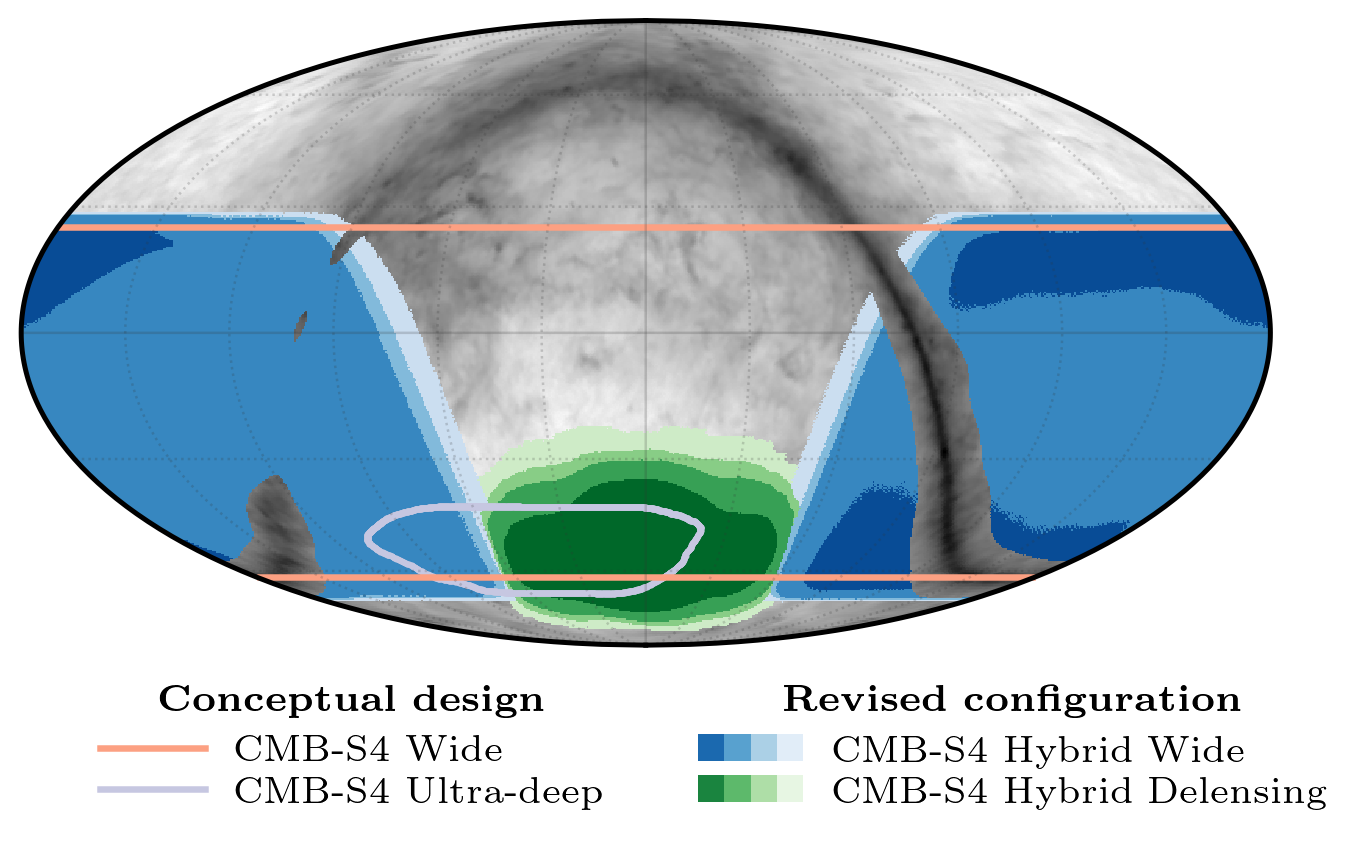

In [13]:
FIGURE2 = all_data['Figure 2']
dust_map = FIGURE2['dust map']
gal_mask = FIGURE2['revised footprint']['galactic mask']
revised_wide = FIGURE2['revised footprint']['wide']
revised_delensing = FIGURE2['revised footprint']['delensing']
pbd_wide = FIGURE2['pbd footprint']['wide']
pbd_deep = FIGURE2['pbd footprint']['ultra-deep']

min1, max1, cmap1 = 0.0, 4.5, plt.cm.Blues
min2, max2, cmap2 = 0.0, 4.5, plt.cm.Greens
pbd_wide_color = plt.cm.Reds(1.5 / 4.5)
pbd_deep_color = plt.cm.Purples(1.5 / 4.5)


fig = plt.figure()

# Dust map
hp.mollview(dust_map, norm='log', coord='GC', hold=True, cbar=False,
            cmap = plt.cm.binary, notext=True, title='')


# Revised configuration
wide_depths = sorted([val for val in set(revised_wide) if val != hp.UNSEEN], reverse=True)
delensing_depths = sorted([val for val in set(revised_delensing) if val != hp.UNSEEN], reverse=True)

revised_wide_remapped = np.full_like(revised_wide, hp.UNSEEN)
revised_delensing_remapped = np.full_like(revised_delensing, hp.UNSEEN)

for i, (wval, dval) in enumerate(zip(wide_depths, delensing_depths), start=1):
    revised_wide_remapped[revised_wide == wval] = i
    revised_delensing_remapped[revised_delensing == dval] = i

for i in range(1, 5):
    del_patch = np.where(revised_delensing_remapped == i, i, hp.UNSEEN)
    alpha2 = np.where((del_patch != hp.UNSEEN) & (gal_mask != 0), 1., 0.)
    hp.mollview(del_patch, alpha=alpha2, cbar=False, cmap=cmap2,
                min=min2, max=max2, reuse_axes=True, notext=True, title='')

    wide_patch = np.where(revised_wide_remapped == i, i, hp.UNSEEN)
    alpha1 = np.where((wide_patch != hp.UNSEEN) & (gal_mask != 0), 1., 0.)
    hp.mollview(wide_patch, alpha=alpha1, cbar=False, cmap=cmap1,
                min=min1, max=max1, reuse_axes=True, notext=True, title='')


# Conceptual design
hp.projplot(pbd_deep['RA'], pbd_deep['DEC'], 'o', lonlat=True, color=pbd_deep_color, ms=1.2, mew=0, ls='none')

npts = 500
ra_dc0 = np.hstack([np.linspace(pbd_wide['RA'][0]+1, pbd_wide['RA'][1]-1, npts),
                    np.linspace(pbd_wide['RA'][0]+1, pbd_wide['RA'][1]-1, npts)])
dec_dc0 = np.hstack([np.linspace(pbd_wide['DEC'][1], pbd_wide['DEC'][1], npts),
                     np.linspace(pbd_wide['DEC'][0], pbd_wide['DEC'][0], npts)])
hp.projplot(ra_dc0, dec_dc0, lonlat=True, color=pbd_wide_color, ls='-')


# Graticules
hp.graticule(lw = 0.5, alpha = 0.2, color = '0.2')


# Legend
class ColormapHandler(mpl.legend_handler.HandlerBase):
    def __init__(self, cmap, vmin, vmax, npatches=4):
        self.cmap = cmap
        self.vmin = vmin
        self.vmax = vmax
        self.npatches = npatches
        super().__init__()

    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        artists = []
        patch_width = width / self.npatches
        for i in range(self.npatches):
            val = (i + 1 - self.vmin) / (self.vmax - self.vmin)
            color = self.cmap(val)
            rect = mpl.patches.FancyBboxPatch(
                (xdescent + i * patch_width, ydescent), patch_width, height,
                boxstyle="square,pad=0",
                facecolor=color, edgecolor='none', transform=trans
            )
            artists.append(rect)
        return artists

class ColumnTitleHandler(mpl.legend_handler.HandlerBase):
    def create_artists(self, legend, orig_handle, xdescent, ydescent, width, height, fontsize, trans):
        rect = mpl.patches.Rectangle((0, 0), 0, 0, visible=False)
        return [rect]

title_left = mpl.patches.Patch(visible=False)
title_right = mpl.patches.Patch(visible=False)

line1_handle = plt.Line2D([], [], ls='-', color=pbd_wide_color)
line2_handle = plt.Line2D([], [], ls='-', color=pbd_deep_color)
wide_handle = mpl.patches.Patch()
del_handle = mpl.patches.Patch()

leg = plt.legend(
    handles=[title_left, line1_handle, line2_handle, title_right, wide_handle, del_handle],
    labels=[r'\textbf{Conceptual design}', 'CMB-S4 Wide', 'CMB-S4 Ultra-deep',
            r'\textbf{Revised configuration}', 'CMB-S4 Hybrid Wide', 'CMB-S4 Hybrid Delensing'],
    handler_map={
        title_left:  ColumnTitleHandler(),
        title_right: ColumnTitleHandler(),
        wide_handle: ColormapHandler(cmap1.reversed(), min1, max1),
        del_handle: ColormapHandler(cmap2.reversed(), min2, max2),
    },
    loc='upper center',
    bbox_to_anchor=(0.555, -0.03),
    ncols=2,
    handlelength=2.8,
    columnspacing=2
)

fig.canvas.draw()
renderer = fig.canvas.get_renderer()
texts = leg.get_texts()
handles = leg.legend_handles

left_x0 = min(handles[i].get_window_extent(renderer).x0 for i in [1, 2])
left_x1 = max(texts[i].get_window_extent(renderer).x1 for i in [1, 2])

right_x0 = min(handles[i].get_window_extent(renderer).x0 for i in [4, 5])
right_x1 = max(texts[i].get_window_extent(renderer).x1 for i in [4, 5])

for title_idx, center_x in [(0, (left_x0 + left_x1) / 2),
                             (3, (right_x0 + right_x1) / 2)]:
    t = texts[title_idx]
    bb = t.get_window_extent(renderer)
    center_y = (bb.y0 + bb.y1) / 2
    new_pos = fig.transFigure.inverted().transform((center_x, center_y))
    t.set_transform(fig.transFigure)
    t.set_position(new_pos)
    t.set_ha('center')

fig_name = 'footprints'
plt.savefig(f'figures/{fig_name}.pdf')

plt.show()
plt.close()

#subprocess.run(["epstopdf", "--gsopt=-dCompatibilityLevel=1.5", f'figures/{fig_name}.eps'], check=True);

### Figure 3: Foregrounds

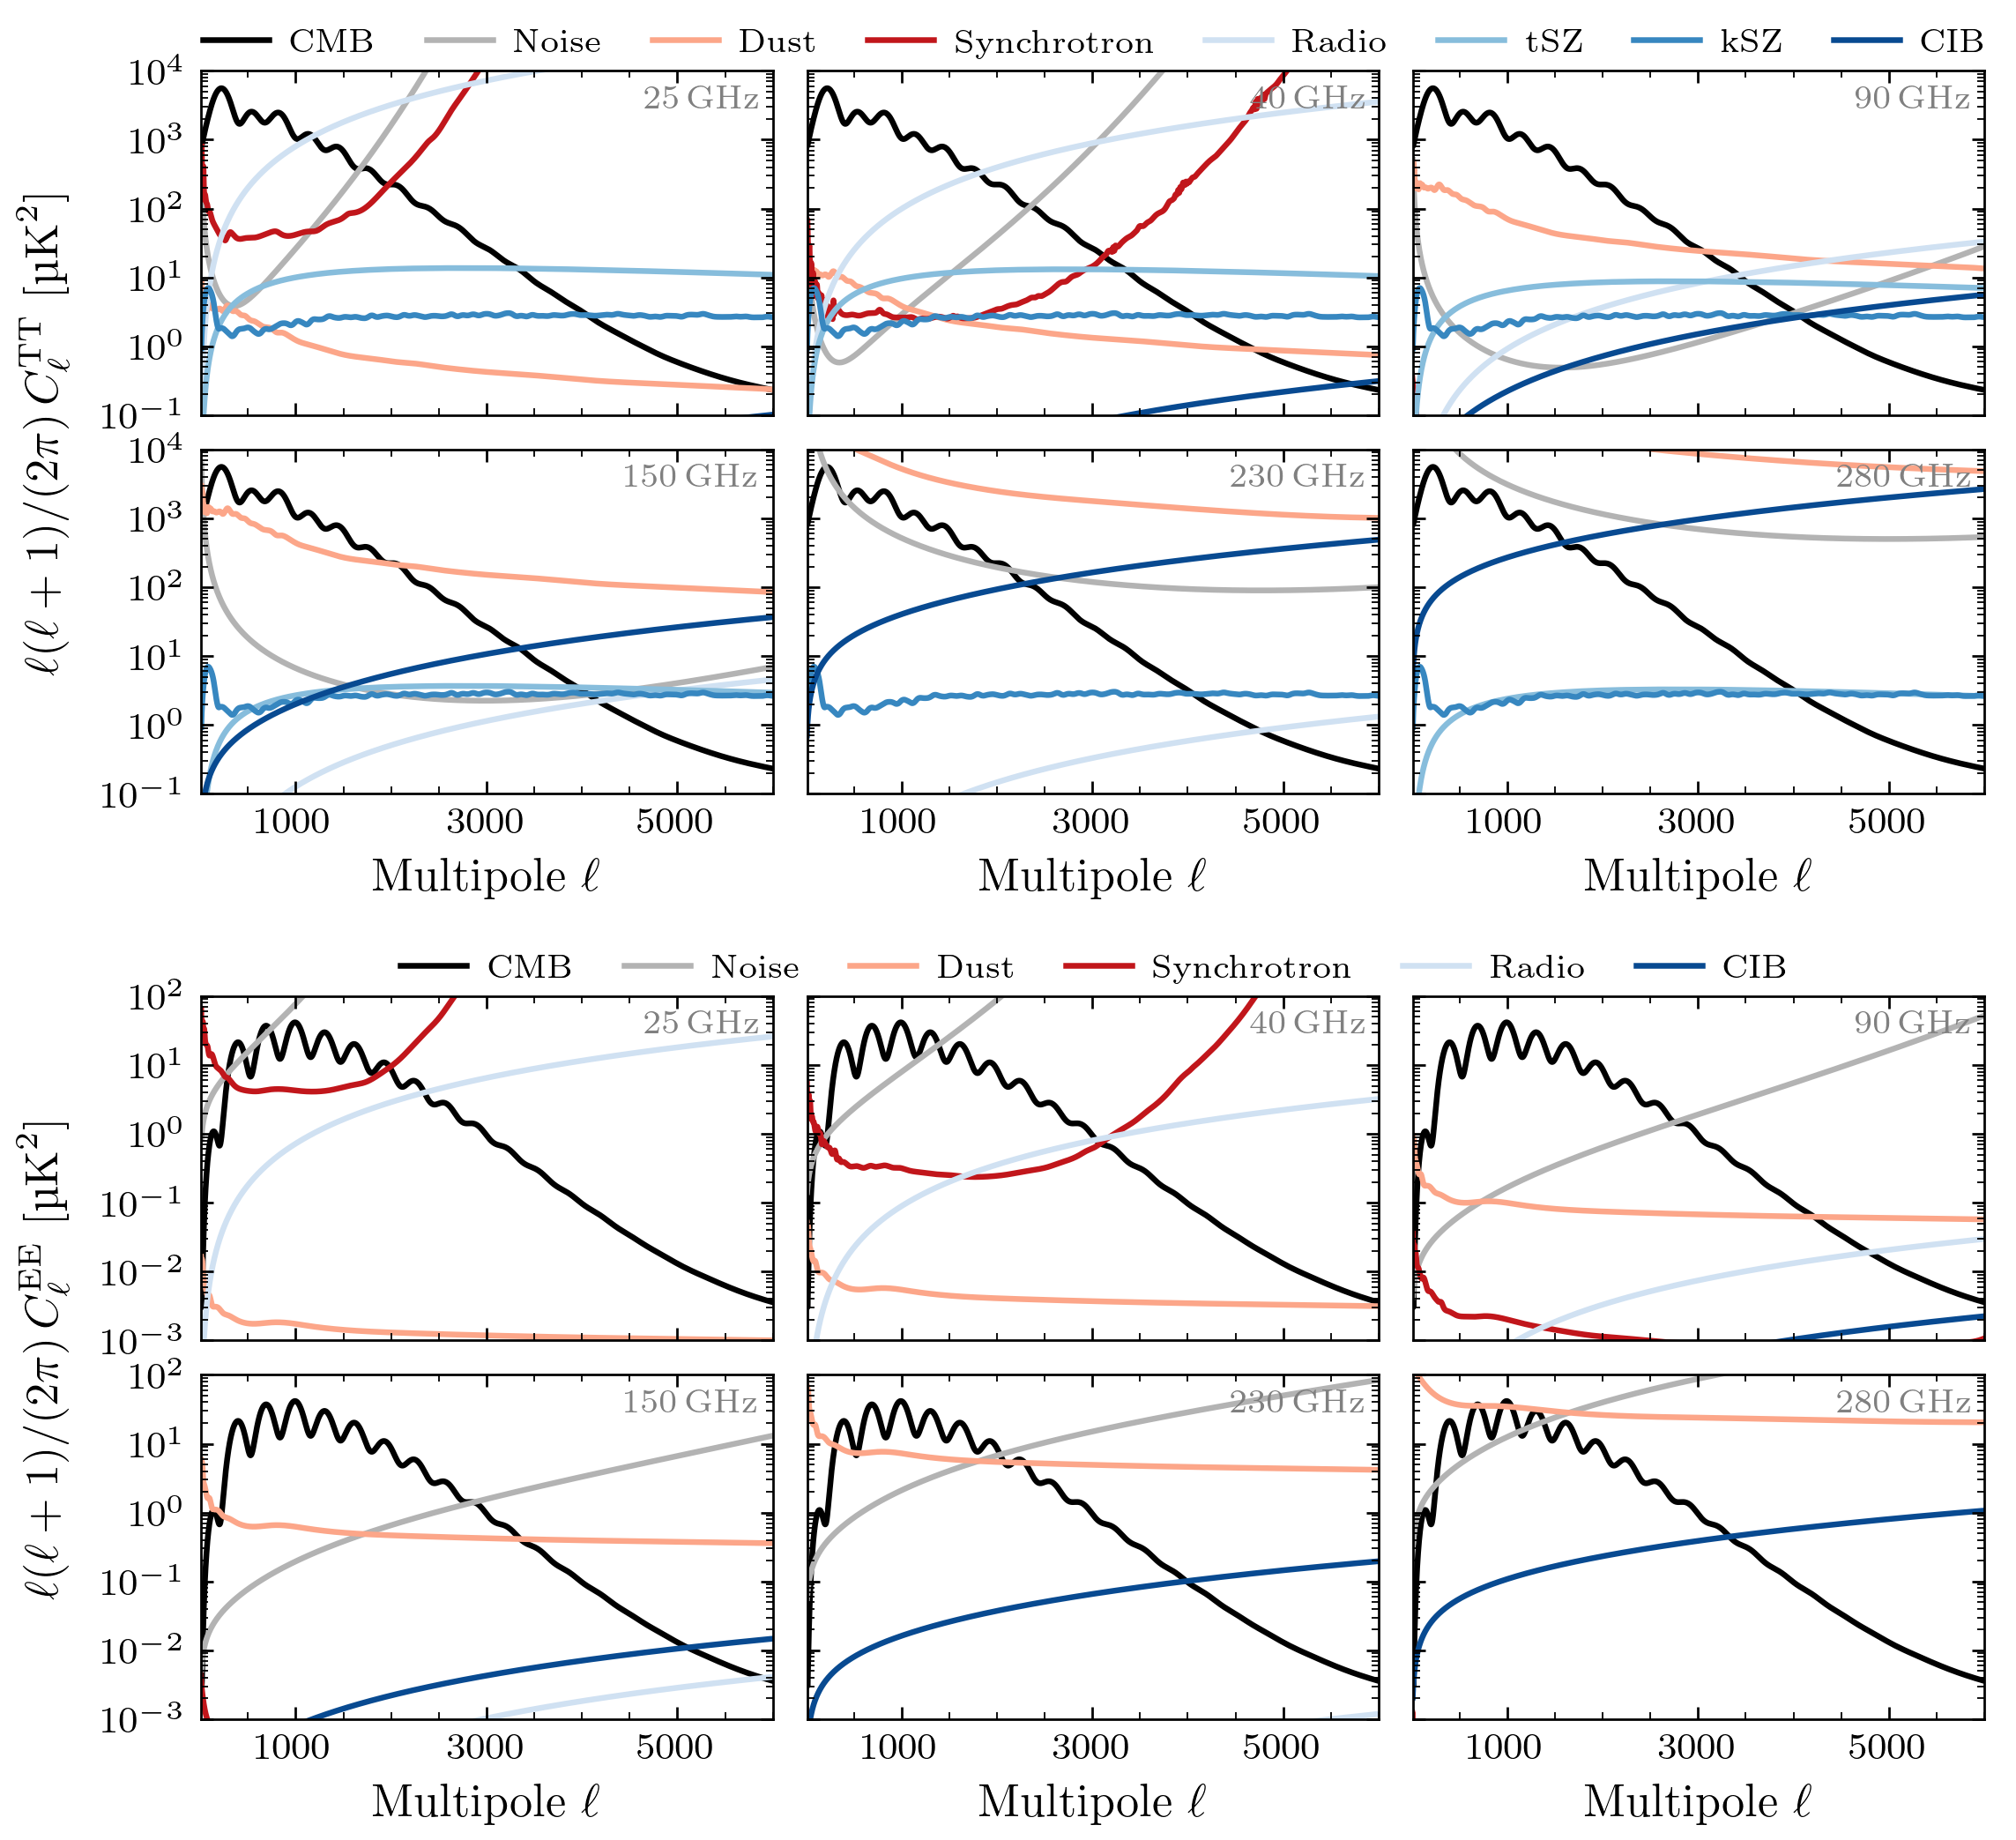

In [14]:
FIGURE3 = all_data['Figure 3']
smoothing = {'TT': {'galdust': 1e1, 'galsync': 2e1}, 'EE': {'galdust': 1e1, 'galsync': 1e1}}

fig = plt.figure(figsize=(7.25, 7.25/1.075))

outer_gs = fig.add_gridspec(2, 1, hspace=0.28)

for num, spec in enumerate(['TT', 'EE']):
    fg_dict = FIGURE3[spec]
    if spec == 'TT':
        ymin, ymax = 1e-1, 1e4
        yticks = [1e-1, 1e-0, 1e1, 1e2, 1e3, 1e4]
        component_skip = []
        legend_anchor = (-0.038, 0.97)
    else:
        ymin, ymax = 1e-3, 1e2
        yticks = [1e-3, 1e-2, 1e-1, 1e-0, 1e1, 1e2]
        component_skip = ['tsz', 'ksz']
        legend_anchor = (0.308, 0.97)

    # Color map
    cmap_base = mpl.colormaps['Blues']
    cmap_subrange = mpl.colors.LinearSegmentedColormap.from_list('Blues_sub', [cmap_base(i) for i in np.linspace(0.2, 0.9, 1000)])
    colors_blue = [cmap_subrange(i) for i in np.linspace(0, 1, 4)]
    cmap_base = mpl.colormaps['Reds']
    cmap_subrange = mpl.colors.LinearSegmentedColormap.from_list('Reds_sub', [cmap_base(i) for i in np.linspace(0.2, 0.9, 1000)])
    colors_red = [cmap_subrange(i) for i in np.linspace(0, 1, 4).reshape(-1, 2).mean(axis=1)]
    component_dict_to_plot = {'cmb':     [r'CMB',         'black'],
                              'noise':   ['Noise',        '0.7'],
                              'galdust': [r'Dust',        colors_red[0]],
                              'galsync': [r'Synchrotron', colors_red[1]],
                              'radio':   [r'Radio',       colors_blue[0]],
                              'tsz':     [r'tSZ',         colors_blue[1]],
                              'ksz':     [r'kSZ',         colors_blue[2]],
                              'cib':     [r'CIB',         colors_blue[3]]}

    inner_gs = outer_gs[num].subgridspec(2, 3, hspace=0.1, wspace=0.06)

    for idx, nu in enumerate(fg_dict['noise']):
        rowval, colval = idx // 3, idx % 3
        ax = fig.add_subplot(inner_gs[rowval, colval], yscale='log')

        ax.set_xlim([10, 6000])
        ax.set_xticks([1000, 3000, 5000])
        ax.set_ylim(ymin, ymax)
        ax.set_yticks(yticks)
        if rowval == 1:
            ax.set_xlabel(r'Multipole $\ell$')
        else:
            plt.setp(ax.get_xticklabels(), visible=False)
        if colval == 0:
            if rowval == 0:
                ax.set_ylabel(r'$\ell (\ell + 1) / (2\pi)\, C_\ell^\mathrm{' + spec + r'}$ $[\si{\micro\kelvin\squared}]$')
                ax.yaxis.set_label_coords(-0.23, -0.05)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)
        ax.yaxis.set_minor_locator(mpl.ticker.LogLocator(base=10., subs=(0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9), numticks=6))
        ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())

        for component in component_dict_to_plot:
            if component in component_skip:
                continue
            curr_cl = fg_dict[component][nu]
            els = np.arange(len(curr_cl))
            dl_fac = els * (els + 1) / 2. / np.pi
            curr_dl = dl_fac * curr_cl
            labval, colorval = component_dict_to_plot[component]
            mask = (curr_dl>ymin/1.5) & (curr_dl<1.5*ymax)
            els, curr_dl = els[mask], curr_dl[mask]
            if component in ['galdust', 'galsync']:
                if len(els) < 3:
                    continue
                curr_dl = np.exp(interpolate(els, np.log(curr_dl), s=smoothing[spec][component])(els))
            ax.plot(els, curr_dl, color=colorval, label=labval)

        ax.text(0.98, 0.96, r'\SI{%s}{GHz}' % (nu), transform=ax.transAxes, ha='right', va='top',
                color='0.5', fontsize=mpl.rcParams['legend.fontsize'])
        if idx == 0:
            ax.legend(bbox_to_anchor=(legend_anchor), loc='lower left', ncol=8,
                       columnspacing=1.49, handletextpad=0.65)

fig_name = 'spectra_foregrounds'
plt.savefig(f'figures/{fig_name}')

plt.show()
plt.close()

subprocess.run(["epstopdf", "--gsopt=-dCompatibilityLevel=1.5", f'figures/{fig_name}.eps'], check=True);

### Figure 4: ILC Residuals for Conceptual Design

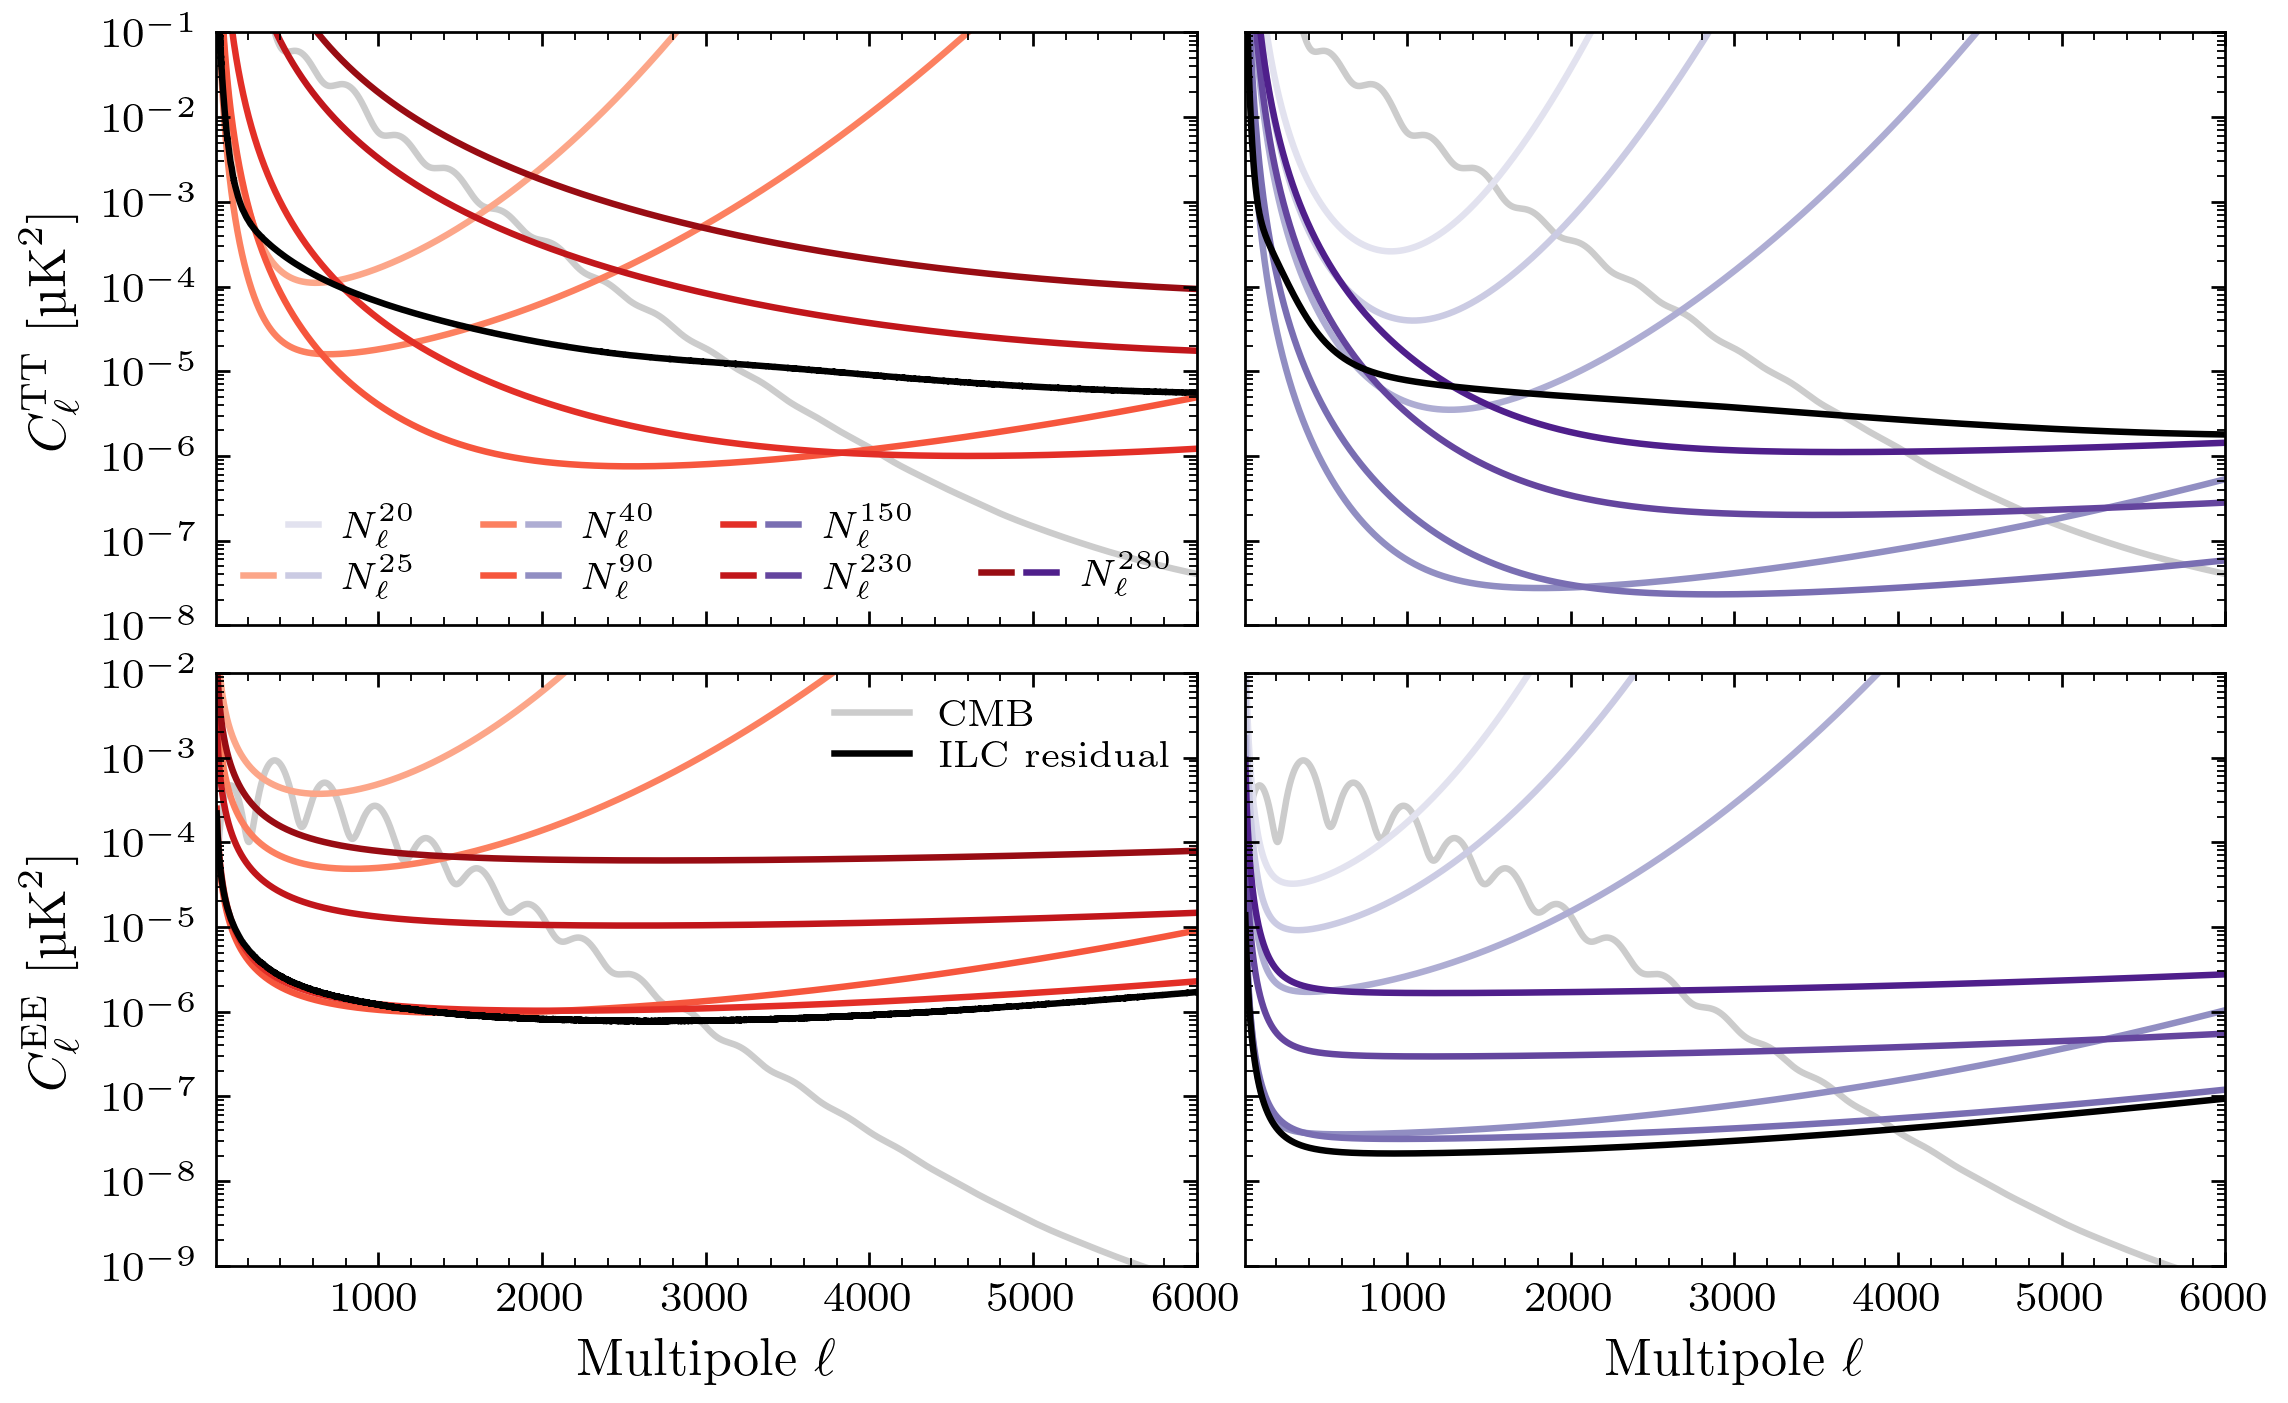

In [15]:
FIGURE4 = all_data['Figure 4']

freq_list = [20, 25, 40, 90, 150, 230, 280]
# Color map
colors = {}
cmap_base = mpl.colormaps['Reds']
cmap_subrange = mpl.colors.LinearSegmentedColormap.from_list('Reds_sub', [cmap_base(i) for i in np.linspace(0.2, 0.9, 1000)])
colors['wide'] = [cmap_subrange(i) for i in np.linspace(0, 1, 7)]
cmap_base = mpl.colormaps['Purples']
cmap_subrange = mpl.colors.LinearSegmentedColormap.from_list('Purples_sub', [cmap_base(i) for i in np.linspace(0.2, 0.9, 1000)])
colors['deep'] = [cmap_subrange(i) for i in np.linspace(0, 1, 7)]

comps_cmb = ['CMB', '0.8']
comps_ilc = ['ILC residual', 'black']
components_to_plot = {'wide': {'cmb': comps_cmb}, 'deep': {'cmb': comps_cmb}}
for num, freq in enumerate(freq_list):
    for survey in colors.keys():
        components_to_plot[survey]['nl_' + str(freq)] = [r'$N_\ell^{' + str(freq) + r'}$', colors[survey][num]]
del components_to_plot['wide']['nl_20']
components_to_plot['wide']['ilc'] = comps_ilc
components_to_plot['deep']['ilc'] = comps_ilc

spec_label = {'wide': 'CMB-S4 Wide survey', 'deep': 'CMB-S4 Ultra-deep survey'}

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(7.2, 7.2/GOLDEN_RATIO))

line_list1 = {}
line_list2 = {}
for ncol, spec in enumerate(FIGURE4):
    if spec == 'TT':
        ymin, ymax = 1e-8, 1e-1
        yticks = [1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
        spec_name = 'tt'
    else:
        ymin, ymax = 1e-9, 1e-2
        yticks = [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
        spec_name = 'ee'
        
    for nrow, survey in enumerate(FIGURE4[spec]):
        ax = axes[ncol, nrow]
        ax.set_xlim([10, 6000])
        ax.set_yscale('log')
        ax.set_ylim([ymin, ymax])
        ax.set_yticks(yticks)
        if nrow == 0:
            ax.set_ylabel(r'$C_\ell^\mathrm{' + spec + r'}$ $[\si{\micro\kelvin\squared}]$', labelpad=5)
        else:
            plt.setp(ax.get_yticklabels(), visible=False)
        if ncol == 0:
            plt.setp(ax.get_xticklabels(), visible=False)
        else:
            ax.set_xlabel(r'Multipole $\ell$')
        ax.yaxis.set_minor_locator(mpl.ticker.LogLocator(base=10., subs=(0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9), numticks=8))
        ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())

        spectra = FIGURE4[spec][survey]
        line_list1[survey] = []
        line_list2[survey] = []
        for typ in components_to_plot[survey]:
            line, = ax.plot(spectra['ell'][11:], spectra[typ][11:], color=components_to_plot[survey][typ][1],
                            label=components_to_plot[survey][typ][0])
            if typ in ['cmb', 'ilc']:
                line_list1[survey].append(line)
            else:
                line_list2[survey].append(line)

        if ncol == 1:
            axes[0, nrow].text(0.02, 0.04, spec_label[survey], transform=ax.transAxes, ha='left', va='bottom',
                               color='0.5', fontsize=mpl.rcParams['legend.fontsize'])

empty = mpl.lines.Line2D([], [], color='none', label='')
line_list2['wide'].insert(0, empty)
legend2_list = [(line_list2['wide'][n], line_list2['deep'][n]) for n in range(len(line_list2['deep']))]
legend2_labels = [l.get_label() for l in line_list2['deep']]
legend2_list.insert(-1, (empty, empty))
legend2_labels.insert(-1, '')
axes[0, 0].legend(legend2_list, legend2_labels,
                  handler_map={tuple: mpl.legend_handler.HandlerTuple(ndivide=None)},
                  loc='lower left', ncol=4, columnspacing=1.8, handletextpad=0.65)
axes[1, 0].legend(handles=line_list1['wide'], loc='upper right', ncol=1, columnspacing=1.9)
        
    
plt.subplots_adjust(hspace=0.08, wspace=0.08/GOLDEN_RATIO)

fig_name = f'spectra_ilc'
plt.savefig(f'figures/{fig_name}')

plt.show()
plt.close()

subprocess.run(["epstopdf", "--gsopt=-dCompatibilityLevel=1.5", f'figures/{fig_name}.eps'], check=True);

### Figure 5: DRAFT Pipeline

In [16]:
FIGURE5 = all_data['Figure 5']
tex_code = FIGURE5['TeX code']

fig_name = 'pipeline'

subprocess.run(["pdflatex", "-interaction=nonstopmode", f"-jobname={fig_name}", r"\input{/dev/stdin}"],
               input=tex_code, text=True, cwd='/tmp/', stdout=subprocess.DEVNULL,  stderr=subprocess.PIPE)
subprocess.run(["pdflatex", "-interaction=nonstopmode", f"-jobname={fig_name}", r"\input{/dev/stdin}"],
               input=tex_code, text=True, cwd='/tmp/', stdout=subprocess.DEVNULL,  stderr=subprocess.PIPE)
generated_pdf = f'/tmp/{fig_name}.pdf'

if os.path.exists(generated_pdf):
    os.replace(generated_pdf, f'{os.getcwd()}/figures/{fig_name}.pdf')
else:
    print("pdfTeX compilation failed. Check /tmp/ for logs.")

### Figure 6: $\mathbf{N}_\mathbf{eff}$ Forecasts as Function of Time

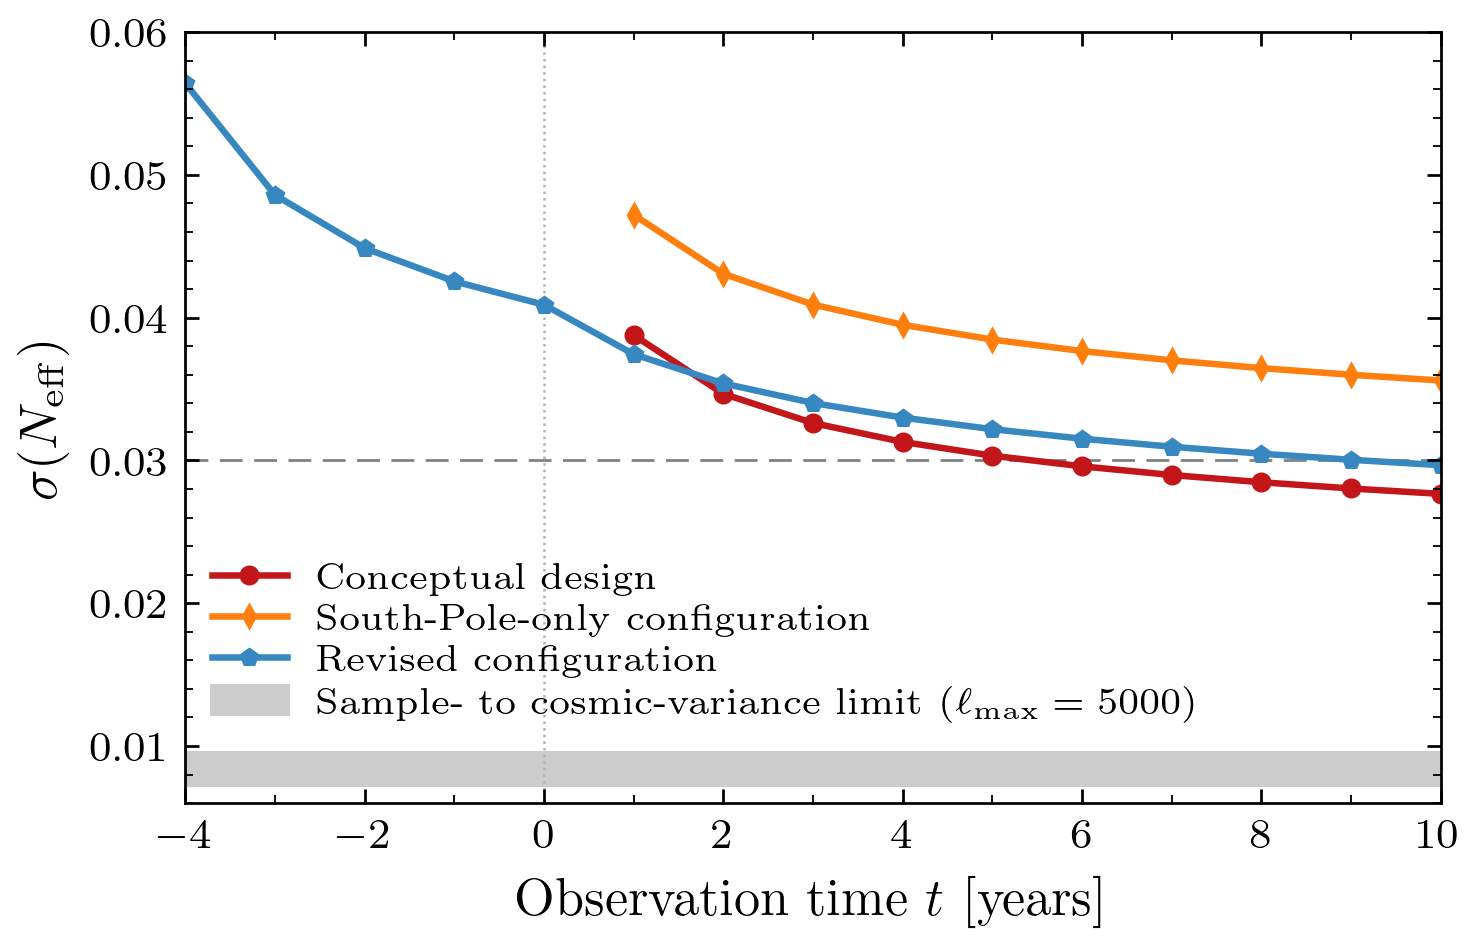

In [17]:
LONG_DASHES = (mpl.rcParams['lines.linewidth']*6.4, mpl.rcParams['lines.linewidth']*3.2)

FIGURE6 = all_data['Figure 6']

plt.figure()

plt.xlabel(r'Observation time $t$ [years]')
plt.xlim([-4, 10])
plt.xticks(np.arange(-3, 10, 2), minor=True)
plt.ylabel(r'$\sigma(N_\mathrm{eff})$')
plt.ylim([0.006, 0.06])

plt.axvline(x=0, linestyle=':', color='0.7', linewidth=0.5)
plt.axhline(y=0.03, linestyle = '--', color='0.5', linewidth=0.55, dashes=LONG_DASHES)

plt.plot(FIGURE6['s4-pbd']['years'], FIGURE6['s4-pbd']['sigma_neff'], 'o-', markersize=3, color=plt.cm.Reds(3.5 / 4.5),
         label='Conceptual design')
plt.plot(FIGURE6['s4-pole']['years'], FIGURE6['s4-pole']['sigma_neff'], 'd-', markersize=2.5, color='C1',
         label='South-Pole-only configuration')
plt.plot(FIGURE6['s4-revised']['years'], FIGURE6['s4-revised']['sigma_neff'], 'p-', markersize=3, color=plt.cm.Blues(3. / 4.5),
         label='Revised configuration')

plt.axhspan(FIGURE6['cvl'], FIGURE6['svl'], color='0.8', label=r'Sample- to cosmic-variance limit ($\ell_\mathrm{max} = 5000$)')

plt.legend(loc='lower left', bbox_to_anchor=(0, 0.071))

fig_name = 'neff_time'
plt.savefig(f'figures/{fig_name}')

plt.show()
plt.close()

subprocess.run(["epstopdf", "--gsopt=-dCompatibilityLevel=1.5", f'figures/{fig_name}.eps'], check=True);

### Figure 7: Survey Design

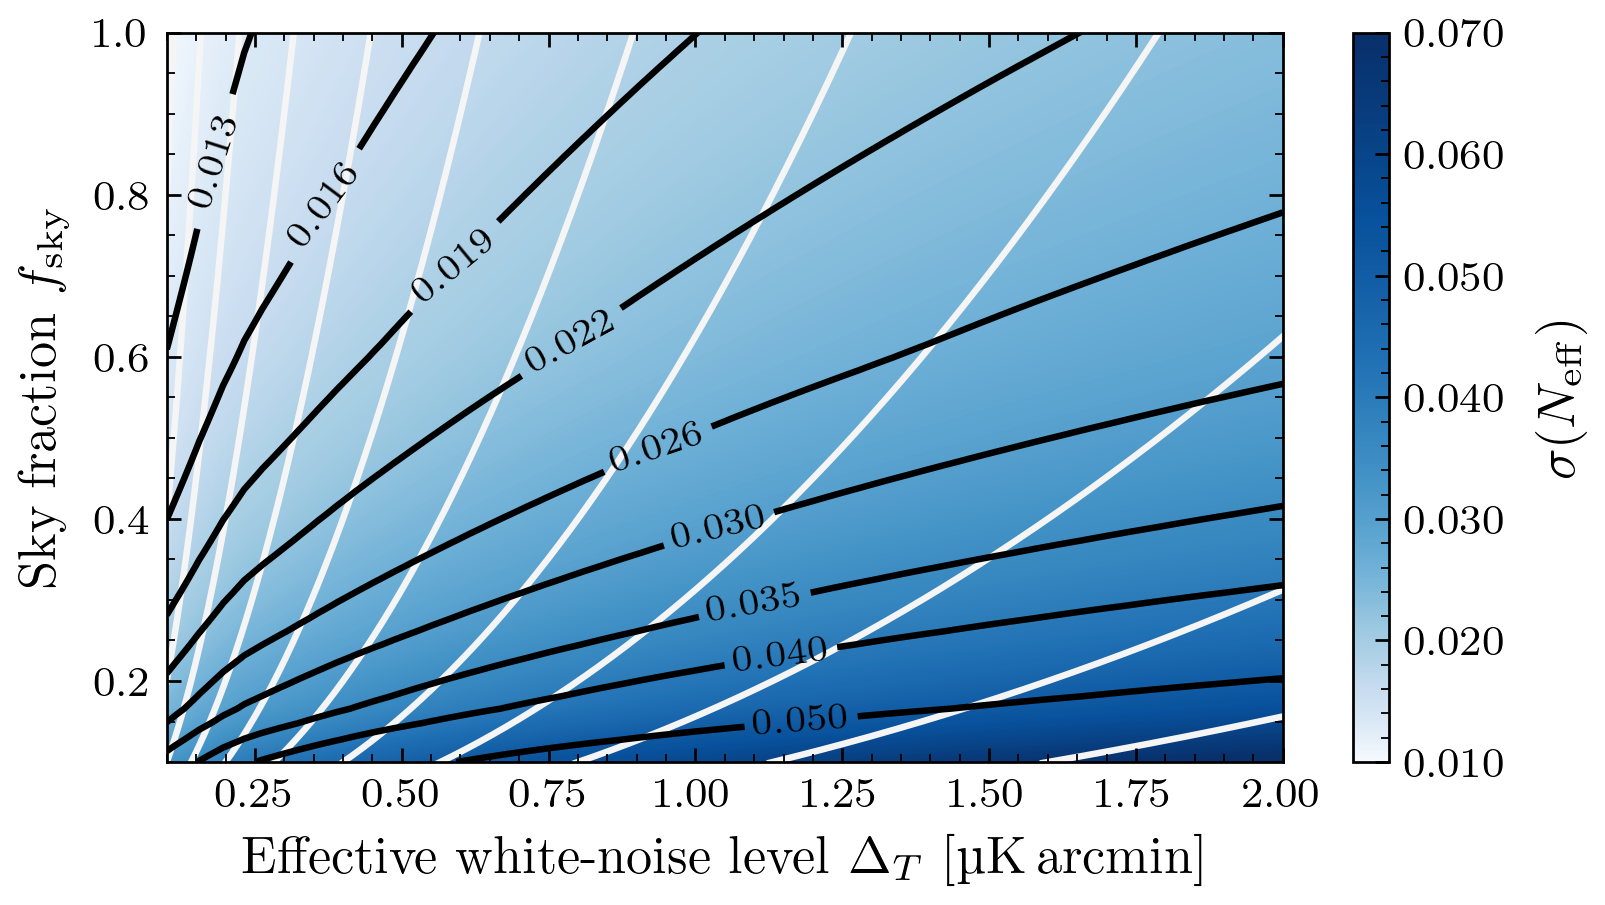

In [18]:
FIGURE7 = all_data['Figure 7']
noise_range, fsky_range, sigma_neff = FIGURE7['noise_range'], FIGURE7['fsky_range'], FIGURE7['sigma_neff']

plot_contours = np.array([0.013, 0.016, 0.019, 0.022, 0.026, 0.030, 0.035, 0.040, 0.050])
plot_contoursf = np.log10(np.arange(0.010, 0.0712, 0.0001))

def const_time_curve(noise, noise_ref, fsky_ref):
    return fsky_ref * (noise / noise_ref) ** 2


plt.figure(figsize = (5., 5./1.9))

plt.xlabel(r'Effective white-noise level $\Delta_T$ $[\si{\micro\kelvin.arcmin}]$')
plt.xlim([0.1, 2.])
plt.ylabel(r'Sky fraction $f_\mathrm{sky}$', labelpad=5)
plt.ylim([0.1, 1.])

contour = plt.contourf(sp_zoom(noise_range, 3, order=2), sp_zoom(fsky_range, 3, order=2),
                       np.log10(sp_zoom(np.transpose(sigma_neff), 3, order=2)),
                       plot_contoursf, cmap='Blues',
                       vmin=np.log10(0.01), vmax=np.log10(0.070))
contour.set_edgecolor("face")

for relative_time in 2.**np.arange(-3, 9, 1):
    noise_range2 = np.linspace(0.1, 2.0, int(10000/np.sqrt(relative_time)))
    fsky = const_time_curve(noise_range2, 0.1*np.sqrt(relative_time), 0.1)
    m = (fsky >= 0.099) & (fsky <= 1.002)
    plt.plot(noise_range2[m], fsky[m], color='0.96')

cp = plt.contour(sp_zoom(noise_range, 3, order=2), sp_zoom(fsky_range, 3, order=2),
                 sp_zoom(np.transpose(sigma_neff), 3, order=2), plot_contours, colors='black',
                 linewidths=mpl.rcParams['lines.linewidth'])
label_positions = [(0.15, 0.85), (0.35, 0.8), (0.6, 0.7), (0.8, 0.6), (0.95, 0.45), (1.05, 0.35), (1.1, 0.30), (1.15, 0.20), (1.18, 0.15)]
plt.clabel(cp, inline=True, fontsize=mpl.rcParams['legend.fontsize'], inline_spacing=22, manual=label_positions)


fig = plt.gcf()
cbar = fig.colorbar(contour, pad=0.05)
cbar.ax.set_ylim(np.log10([0.01, 0.07]))
tick_loc = np.arange(0.01, 0.071, 0.01)
cbar.set_ticks(np.log10(tick_loc))
cbar.set_ticklabels(['{:1.3f}'.format(loc) for loc in tick_loc])
minor_loc = np.arange(0.010, 0.0701, 0.002)
cbar.ax.yaxis.set_minor_locator(mpl.ticker.FixedLocator(np.log10(minor_loc)))
cbar.set_label(r'$\sigma(N_\mathrm{eff})$', rotation='vertical', labelpad=11., verticalalignment='center')


fig_name = 'neff_optimization'
plt.savefig(f'figures/{fig_name}')

plt.show()
plt.close()

subprocess.run(["epstopdf", "--gsopt=-dCompatibilityLevel=1.5", f'figures/{fig_name}.eps'], check=True);

### Figure 8: $\mathbf{N}_\mathbf{eff}$ Forecasts as Function of Maximum Multipole

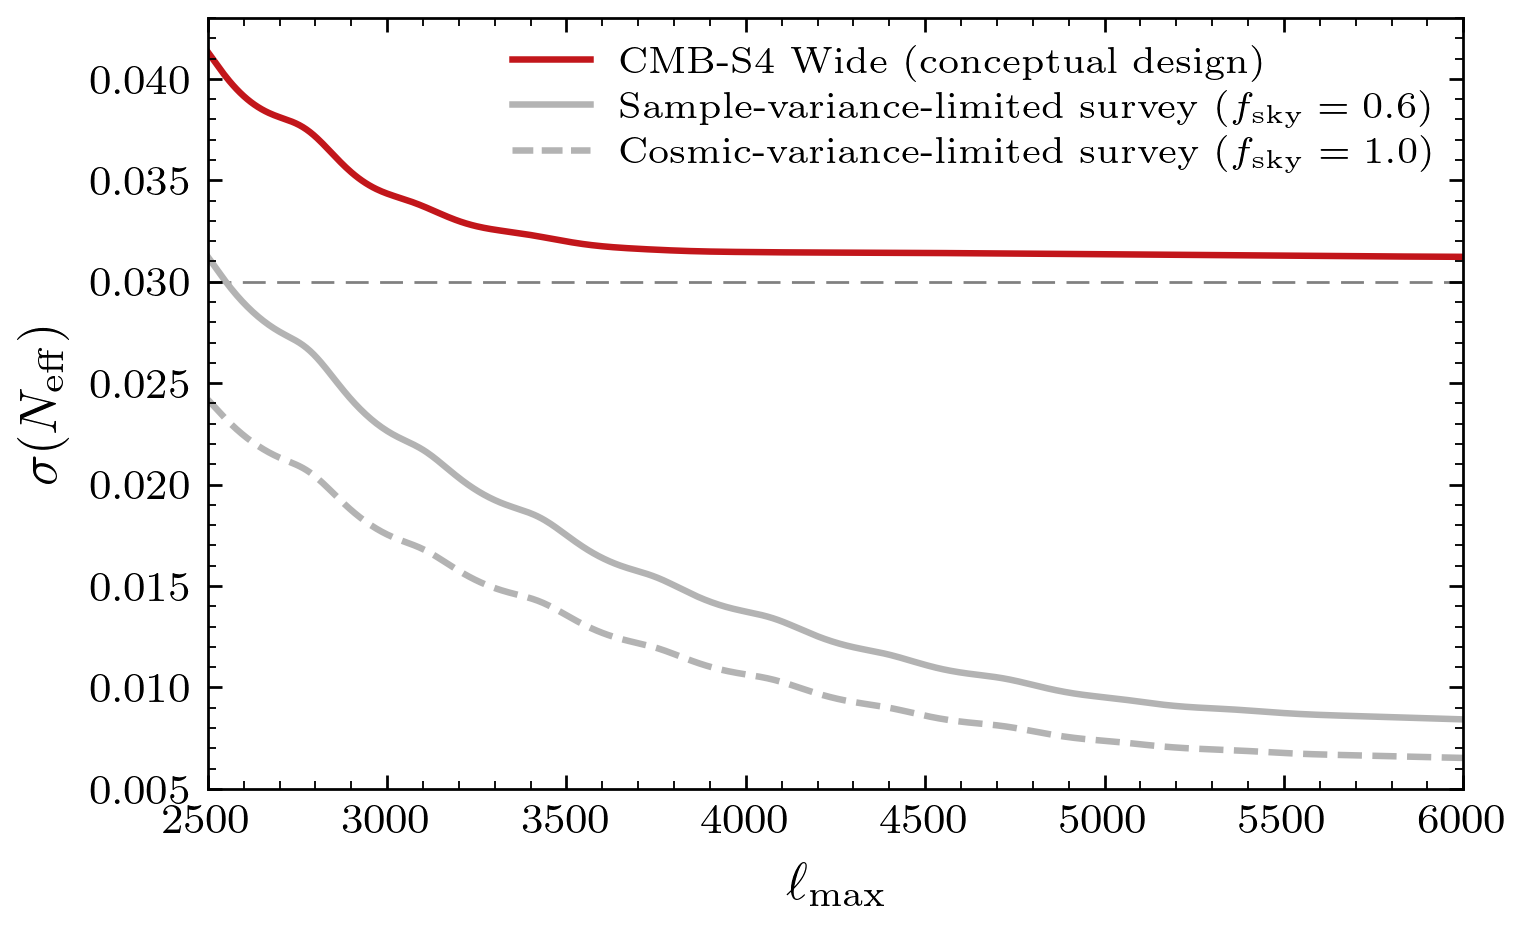

In [19]:
LONG_DASHES = (mpl.rcParams['lines.linewidth']*6.4, mpl.rcParams['lines.linewidth']*3.2)

FIGURE8 = all_data['Figure 8']

plt.figure()

plt.xlabel(r'$\ell_\mathrm{max}$')
plt.xlim([2500, 6000])
plt.ylabel(r'$\sigma(N_\mathrm{eff})$')
plt.ylim([0.005, 0.043])

plt.plot(FIGURE8['s4']['ell_max'], FIGURE8['s4']['sigma_neff'], color=plt.cm.Reds(3.5 / 4.5),
         label='CMB-S4 Wide (conceptual design)')
plt.axhline(y=0.03, linestyle = '--', color='0.5', linewidth=0.55, dashes=LONG_DASHES)


plt.plot(FIGURE8['cvl']['ell_max'], FIGURE8['cvl']['sigma_neff']/np.sqrt(0.6), color='0.7',
         label=r'Sample-variance-limited survey ($f_\mathrm{sky} = 0.6$)')
plt.plot(FIGURE8['cvl']['ell_max'], FIGURE8['cvl']['sigma_neff'], '--', color='0.7',
         dashes=list(np.asarray(mpl.rcParams['lines.dashed_pattern'])*1.006))
plt.plot(np.nan, np.nan, '--', dashes=(3.2, 1.3), color='0.7',
         label=r'Cosmic-variance-limited survey ($f_\mathrm{sky} = 1.0$)')


plt.legend(loc='best', handlelength=2.08)

fig_name = 'neff_ellmax'
plt.savefig(f'figures/{fig_name}')

plt.show()
plt.close()

subprocess.run(["epstopdf", "--gsopt=-dCompatibilityLevel=1.5", f'figures/{fig_name}.eps'], check=True);